In [ ]:
from astropy.table import Table

### 1. The Cumulative GWTC-4, which contains all the events from O1 to O4  

Source: [GWOSC Event Catalog](https://gwosc.org/eventapi/html/GWTC/)


In [39]:
# Load the cumulative GWTC-4 catalog (O1–O4 events) from local CSV file
cumulative_GWTC4 = Table.read("./data/Cumulative_GWTC-4.0.csv", format="ascii.csv")

In [40]:
# Select only events belonging to the O4a catalog
O4a_catalog = cumulative_GWTC4[
    (cumulative_GWTC4["catalog"] == "GWTC-4.0") & (cumulative_GWTC4["p_astro"] >= 0.5)
]

# Quick check: display the number of events in O4a
print(f"Number of events in O4a catalog: {len(O4a_catalog)}")

Number of events in O4a catalog: 129



##### `Note on GWTC-4 Catalog`

There appears to be a small discrepancy in the **abstract** of the GWTC-4 catalog ([GWTC-4.0 Results](https://dcc.ligo.org/DocDB/0196/P2400386/012/GWTC-4.0_results_v12.pdf)).  
The document states that the number of events with $p_{\mathrm{astro}} \geq 0.5$ is **128**, whereas by direct counting it should be **129**.  

In practice, the number **128** corresponds to events with $p_{\mathrm{astro}} > 0.5$, while including the equality ($\geq 0.5$) yields **129 events**.  

This difference comes from the candidate **GW230615_160825**, which has $p_{\mathrm{astro}} = 0.5$. If one includes this event, the count is 129;  
if one adopts the strict threshold $p_{\mathrm{astro}} > 0.5$, the count is 128.  


The same value (**128**) is also reported in the LVK *Rates & Populations* paper ([O4a astro distribution](https://dcc.ligo.org/DocDB/0191/P2400004/010/O4a_astrodist_final_lvk_circulation.pdf)).



In what follows, we adopt ($p_{\mathrm{astro}} >= 0.5$). However, **Table I** ([GWTC-4.0 Results](https://dcc.ligo.org/DocDB/0196/P2400386/012/GWTC-4.0_results_v12.pdf)) indicates that `GW230630_070659` may  
be of instrumental origin; pending confirmation, we exclude this event,  
which leaves an effective total of 128 events while keeping the ($p_{\mathrm{astro}} >= 0.5$) threshold.


In [ ]:
O4a_catalog = cumulative_GWTC4[
    (cumulative_GWTC4["catalog"] == "GWTC-4.0")
    & (cumulative_GWTC4["name"] != "GW230630_070659")
    & (cumulative_GWTC4["p_astro"] >= 0.5)
]

print(f"Number of events in O4a catalog: {len(O4a_catalog)}")

In [ ]:
SNR_O4a_catalog = O4a_catalog["network_matched_filter_snr"]

SNR_GWTC4 = cumulative_GWTC4[
    (cumulative_GWTC4["name"] != "GW230630_070659")
    & (cumulative_GWTC4["p_astro"] >= 0.5)
]["network_matched_filter_snr"]
len(SNR_GWTC4)

10.4
9.6
25.9
14.8
13.4
11.3
8.2
34.7
14.0
10.0
9.4


In [30]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


<Figure size 640x480 with 0 Axes>

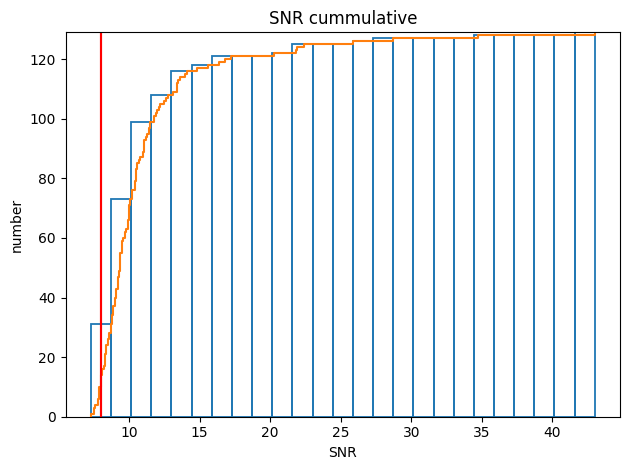

In [46]:
import seaborn as sns
from matplotlib import pyplot as plt

# Figure Plot
plt.clf()
fig, axs2 = plt.subplots(tight_layout=True)

axs2 = sns.histplot(
    SNR_O4a_catalog, stat="count", cumulative=True, bins=25, fill=False, legend=True
)
axs2 = sns.ecdfplot(SNR_O4a_catalog, stat="count")
axs2.axvline(x=8, color="red")
axs2.axvline(x=8, color="red")
axs2.set_ylabel("number")
axs2.set_title("SNR cummulative")
plt.xlabel("SNR")
plt.show()

In [80]:
color1, color2, color3 = sns.color_palette("rocket", 3)

<Figure size 640x480 with 0 Axes>

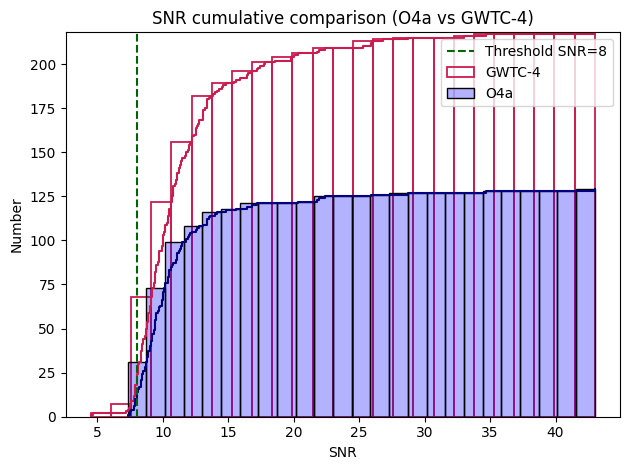

In [103]:
import seaborn as sns
from matplotlib import pyplot as plt

color1, color2, color3 = sns.color_palette("rocket", 3)

plt.clf()
fig, ax = plt.subplots(tight_layout=True)


# GWTC-4 cumulative histogram (transparent)
sns.histplot(
    SNR_GWTC4,
    stat="count",
    cumulative=True,
    bins=25,
    fill=False,
    color=color2,
    alpha=1,
    label="GWTC-4",
    ax=ax,
)

# ECDF GWTC-4 (transparent)
sns.ecdfplot(SNR_GWTC4, stat="count", color=color2, ax=ax)

# O4a cumulative histogram
sns.histplot(
    SNR_O4a_catalog,
    stat="count",
    cumulative=True,
    bins=25,
    fill=True,
    color="blue",
    alpha=0.3,
    label="O4a",
    ax=ax,
)

# ECDF O4a
sns.ecdfplot(SNR_O4a_catalog, stat="count", color="navy", ax=ax)

# Vertical line SNR=8
ax.axvline(x=8, ls="--", color="darkgreen", label="Threshold SNR=8")

ax.set_ylabel("Number")
ax.set_xlabel("SNR")
ax.set_title("SNR cumulative comparison (O4a vs GWTC-4)")
ax.legend()

plt.show()

In [ ]:
import requests

# Endpoint GraceDB pour les événements O4a
url = "https://gracedb.ligo.org/api/superevents/"
params = {
    "observing_run": "O4a",  # O4 events
    "state": "public",  # seulement les événements publics
    "format": "json",
}

response = requests.get(url, params=params)
data = response.json()

In [ ]:
import requests

url = "https://gracedb.ligo.org/api/superevents/"
params = {"format": "json"}

response = requests.get(url, params=params)

response.raise_for_status()
superevents_alerts = response.json()

In [ ]:
superevents_alerts

In [ ]:
from astropy.time import Time


# --- helpers ---
def parse_created_utc(created_str: str) -> Time:
    s = created_str.replace(" UTC", "")
    return Time(s, scale="utc", format="iso")

In [ ]:
O4a_start = Time("2023-05-24 15:00:00", scale="utc", format="iso")
O4a_end = Time("2024-01-16 16:00:00", scale="utc", format="iso")

O4a_end

In [11]:
url = "https://gracedb.ligo.org/api/superevents/?format=json&count=1000"

snr_coincident_O4a = []
while url:
    superevents_alerts = requests.get(url, params=params, timeout=120).json()

    for se in superevents_alerts.get("superevents", []):
        detection_date = parse_created_utc(se["created"])
        # if   O4a_start <= detection_date <= O4a_end:
        ci = (
            se.get("preferred_event_data", {})
            .get("extra_attributes", {})
            .get("CoincInspiral", {})
        )
        snr = ci.get("snr")
        print(snr)
        if snr is not None:
            snr_coincident_O4a.append(snr)

    url = (data.get("links") or {}).get("next")
    print(url)

None
None
None
None
None
None
None
None
None
None
https://gracedb.ligo.org/api/superevents/?count=10&format=json&observing_run=O4a&start=10&state=public
None
None
None
None
None
None
None
None
None
None
https://gracedb.ligo.org/api/superevents/?count=10&format=json&observing_run=O4a&start=10&state=public
None
None
None
None
None
None
None
None
None
None
https://gracedb.ligo.org/api/superevents/?count=10&format=json&observing_run=O4a&start=10&state=public
None
None
None
None
None
None
None
None
None
None
https://gracedb.ligo.org/api/superevents/?count=10&format=json&observing_run=O4a&start=10&state=public


KeyboardInterrupt: 

In [ ]:
"https://gracedb.ligo.org/api/superevents/?count=2000&format=json&observing_run=O4a&start=2000&state=public"

In [12]:
import requests

url = "https://gracedb.ligo.org/api/superevents/?count=2000&format=json&observing_run=O4a&start=2000&state=public"
params = {"format": "json"}

response = requests.get(url, params=params)

response.raise_for_status()
superevents_alerts = response.json()

In [27]:
snr_coincident_O4a = []
for se in superevents_alerts.get("superevents", []):
    detection_date = parse_created_utc(se["created"])
    # if   O4a_start <= detection_date <= O4a_end:

    ci = se["preferred_event_data"]["extra_attributes"]

    print(ci)
    snr = ci.get("snr")
    # print(detection_date)
    if snr is not None:
        snr_coincident_O4a.append(snr)

{'MultiBurst': {'ifos': 'H1,L1', 'single_ifo_times': '1419915790.8832,1419915790.8850'}}
{}
{'SingleInspiral': [{'ifo': 'L1', 'end_time': 1419903646, 'end_time_ns': 730957031}, {'ifo': 'H1', 'end_time': 1419903646, 'end_time_ns': 733398438}]}
{'SingleInspiral': [{'ifo': 'H1', 'end_time': 1419883587, 'end_time_ns': 468750000}, {'ifo': 'L1', 'end_time': 1419883587, 'end_time_ns': 463867188}]}
{'SingleInspiral': [{'ifo': 'H1', 'end_time': 1419868471, 'end_time_ns': 97167969}, {'ifo': 'L1', 'end_time': 1419868471, 'end_time_ns': 91796875}]}
{'SingleInspiral': [{'ifo': 'H1', 'end_time': 1419862212, 'end_time_ns': 668437004}, {'ifo': 'L1', 'end_time': 1419862212, 'end_time_ns': 671464443}, {'ifo': 'V1', 'end_time': 1419862212, 'end_time_ns': 660644531}]}
{'MultiBurst': {'ifos': 'H1,L1', 'single_ifo_times': '1419855012.2887,1419855012.2841'}}
{'MultiBurst': {'ifos': 'H1,L1', 'single_ifo_times': '1419853235.6313,1419853235.6355'}}
{'SingleInspiral': [{'ifo': 'H1', 'end_time': 1419852256, 'end_

In [18]:
ci = (
    se.get("preferred_event_data", {})
    .get("extra_attributes", {})
    .get("CoincInspiral", {})
)
ci

{}

In [28]:
se

{'superevent_id': 'S231110b',
 'gw_id': None,
 'category': 'Production',
 'created': '2023-11-10 00:13:50 UTC',
 'submitter': 'emfollow',
 'em_type': None,
 't_start': 1383610382.431839,
 't_0': 1383610382.4766,
 't_end': 1383610382.521361,
 'far': 8.54733e-06,
 'time_coinc_far': None,
 'space_coinc_far': None,
 'labels': ['EM_READY',
  'SKYMAP_READY',
  'DQOK',
  'LOW_SIGNIF_PRELIM_SENT',
  'LOW_SIGNIF_LOCKED'],
 'links': {'labels': 'https://gracedb.ligo.org/api/superevents/S231110b/labels/',
  'logs': 'https://gracedb.ligo.org/api/superevents/S231110b/logs/',
  'files': 'https://gracedb.ligo.org/api/superevents/S231110b/files/',
  'self': 'https://gracedb.ligo.org/api/superevents/S231110b/',
  'voevents': 'https://gracedb.ligo.org/api/superevents/S231110b/voevents/',
  'emobservations': 'https://gracedb.ligo.org/api/superevents/S231110b/emobservations/'},
 'preferred_event_data': {'submitter': 'waveburst',
  'created': '2023-11-10 00:13:49 UTC',
  'group': 'Burst',
  'pipeline': 'CWB